# Superstore Profitability Analysis

## Introduction

A business can generate strong sales and still lose money on part of its transactions. This analysis investigates whether that is happening within the Superstore business and, more importantly, identifies where the profitability problem comes from.

Using transaction data from 2021–2025, the analysis starts by evaluating the overall financial performance of the business before breaking profitability down by time, customer characteristics, region, discount levels, marketing channels, and coupon activity.

The central focus of the investigation is **profitability** rather than sales alone. The goal is to understand which factors are associated with declining margins and where actual losses are being generated.

The analysis reveals a clear pattern: while the business is profitable overall, profitability declines progressively as discount levels increase, with all identified loss-making transactions occurring at discounts above 30%. The investigation then examines the customer types, regions, marketing channels, and coupon activity associated with these losses to understand the scale and concentration of the problem.

The analysis concludes by translating these findings into business actions aimed at protecting profit while maintaining the sales and customer value generated through promotional strategies.


In [1]:
#import the necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import matplotlib.ticker as ticker
import plotly.express as px

In [2]:
# Load the validated Golden Dataset
df = pd.read_csv(
    'superstore_golden_dataset.csv',
    parse_dates=['order_date']
)

In [34]:
# 1. Show all columns instead of truncating with...
pd.set_option('display.max_columns', None)

# 2. Get dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("-" * 50) # just a separator line

# 3. Preview the first 5 rows with all columns visible
df.head()



Number of rows: 138116
Number of columns: 48
--------------------------------------------------


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,discount_rate,discount_band
0,ORD-456592,2021-01-01,07:52:25,Completed,Website,CUST-001023,Lori Leon,60,Male,Consumer,Loyal,Port Patrickland,Sharjah,UAE,North,39852,Credit Card,Paid,AED,Express,WH-012,3.0,3.0,On Time,Not Returned,No Return,4.5,Positive,Absolutely love this product! Exceeded all exp...,YouTube,Default_Campaign,NaN,32,21,3,333.90,54.63,13.96,32.01,325.24,116.37,176.86,54.38,2495.67,True,5,0.163612,Medium (11-20%)
1,ORD-987181,2021-01-01,07:11:05,Completed,Mobile App,CUST-020910,Kevin Sutton,56,Male,VIP,Loyal,East Amber,Texas,USA,South,77802,Credit Card,Paid,USD,Economy,WH-016,9.0,9.0,On Time,Not Returned,No Return,3.2,Neutral,Mixed feelings about this purchase.,Direct,Default_Campaign,SAVE31,6,0,2,53.46,4.62,3.41,12.58,64.83,24.81,27.44,42.33,2151.95,True,5,0.086420,Low (1-10%)
2,ORD-285824,2021-01-01,13:34:21,Completed,Website,CUST-016482,Stephen Lee,71,Female,Business,Loyal,Stanleymouth,England,UK,North,4719,Debit Card,Paid,GBP,Express,WH-012,6.0,3.0,Delayed,Not Returned,No Return,3.2,Neutral,Average product. Could be better.,Affiliate,Influencer_Program,NaN,55,34,2,451.89,5.95,89.19,17.34,552.47,235.57,299.56,54.22,10051.77,True,6,0.013167,Low (1-10%)
3,ORD-111272,2021-01-01,05:54:43,Returned,Marketplace,CUST-012816,Daniel Alvarado,51,Male,Business,Loyal,Lake Danielland,Michigan,USA,Central,32516,Digital Wallet,Refunded,USD,Same Day,WH-009,NaN,NaN,Cancelled,Returned,Late Delivery,NaN,NaN,NaN,Organic Search,NaN,NaN,0,0,3,892.31,0.00,62.46,38.84,993.61,604.56,350.21,35.25,7432.75,True,5,0.000000,No Discount
4,ORD-740177,2021-01-01,03:07:42,Completed,Mobile App,CUST-021644,Caroline Davis,56,Female,Consumer,Loyal,East Shelialand,Florida,USA,South,85761,Credit Card,Paid,USD,Economy,WH-007,5.0,5.0,On Time,Not Returned,No Return,3.9,Positive,Good product. Works as expected.,Affiliate,NaN,NaN,24,3,2,233.80,7.41,15.85,3.35,245.59,78.32,163.92,66.75,6216.44,True,6,0.031694,Low (1-10%)


In [4]:
# Core sales and profitability performance indicators
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Net Sales',
        'Total Profit',
        'Profit Margin',
        'Total Orders',
        'Total Quantity Sold',
        'Average Order Value',
        'Total Discount Amount'
    ],
    'Value': [
        df['net_sales'].sum(),
        df['profit'].sum(),
        df['profit'].sum() / df['net_sales'].sum(),
        df['order_id'].nunique(),
        df['quantity'].sum(),
        df['net_sales'].sum() / df['order_id'].nunique(),
        df['discount_amount'].sum()
    ]
})

kpi_summary['Value'] = [
    f"${kpi_summary.loc[0, 'Value']:,.2f}",
    f"${kpi_summary.loc[1, 'Value']:,.2f}",
    f"{kpi_summary.loc[2, 'Value']:.2%}",
    f"{kpi_summary.loc[3, 'Value']:,.0f}",
    f"{kpi_summary.loc[4, 'Value']:,.0f}",
    f"${kpi_summary.loc[5, 'Value']:,.2f}",
    f"${kpi_summary.loc[6, 'Value']:,.2f}"
]

kpi_summary

,KPI,Value
0,Total Net Sales,"$177,134,263.74"
1,Total Profit,"$76,146,395.76"
2,Profit Margin,42.99%
3,Total Orders,"138,116"
4,Total Quantity Sold,"775,555"
5,Average Order Value,"$1,282.50"
6,Total Discount Amount,"$32,819,346.82"


## Exploratory Data Analysis (EDA)

This section explores the business's sales and profitability performance to identify key trends, performance drivers, and areas requiring further investigation.

### Overall Sales & Profitability

This analysis establishes the overall financial performance of the business by examining net sales, profit, and profit margin before investigating specific business dimensions.

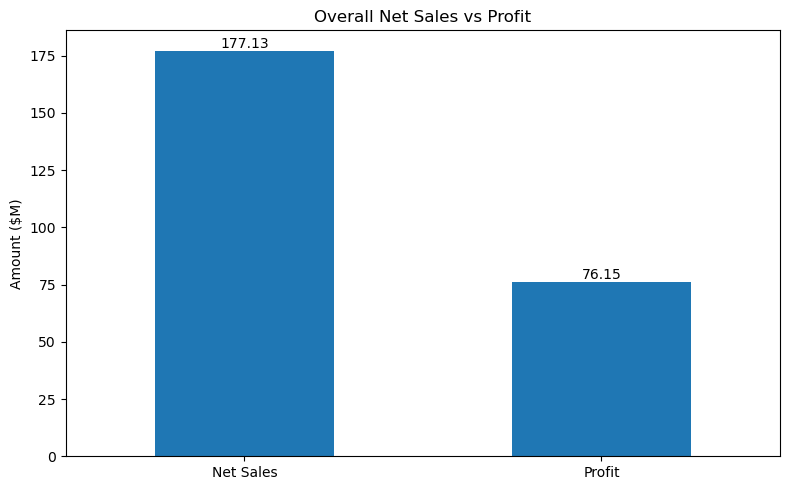

In [5]:
# Overall sales and profit performance
overall_profitability = pd.Series({
    'Net Sales': df['net_sales'].sum() / 1e6,
    'Profit': df['profit'].sum() / 1e6
})

ax = overall_profitability.plot(
    kind='bar',
    figsize=(8, 5)
)

ax.set_title('Overall Net Sales vs Profit')
ax.set_ylabel('Amount ($M)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

The business generated **$177.13 million in net sales** and **$76.15 million in profit** across the period analyzed, resulting in an overall **profit margin of 42.99%**.

This indicates strong overall profitability and provides a baseline for investigating the factors driving financial performance. The subsequent analysis will examine product, regional, customer, and discount-level performance to identify where profit is being generated and where financial losses are concentrated.

In [6]:
# Monthly sales and profit performance
monthly_performance = (
    df.set_index('order_date')
      .resample('ME')[['net_sales', 'profit']]
      .sum()
)

monthly_performance

,net_sales,profit
order_date,,
2021-01-31,2374415.22,1129764.43
2021-02-28,1905413.15,900452.55
2021-03-31,2753256.18,1298951.77
2021-04-30,2469384.78,1178381.90
2021-05-31,2546555.37,1219361.44
2021-06-30,2710208.64,1292627.89
2021-07-31,2894416.72,1143965.61
2021-08-31,3220659.48,1526095.90
2021-09-30,2720931.59,1224683.15


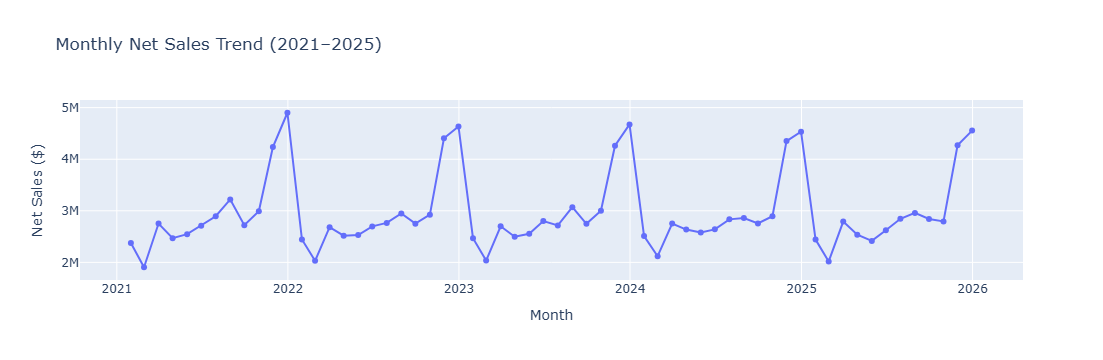

In [7]:
# Interactive monthly net sales trend
monthly_sales = (
    df.set_index('order_date')['net_sales']
      .resample('ME')
      .sum()
      .reset_index()
)

monthly_sales['month'] = monthly_sales['order_date'].dt.strftime('%b %Y')

fig = px.line(
    monthly_sales,
    x='order_date',
    y='net_sales',
    markers=True,
    title='Monthly Net Sales Trend (2021–2025)',
    labels={
        'order_date': 'Month',
        'net_sales': 'Net Sales ($)'
    },
    hover_data={
        'order_date': False,
        'month': True
    }
)

fig.update_traces(
    hovertemplate='<b>%{customdata[0]}</b><br>Net Sales: $%{y:,.2f}<extra></extra>'
)

fig.show()

The business demonstrates stable performance with a clear recurring seasonal cycle: sales and profit strengthen toward year-end, peak around December, and decline sharply in January–February.

In [8]:
# Monthly profit margin performance
monthly_performance['profit_margin'] = (
    monthly_performance['profit'] / monthly_performance['net_sales']
)

monthly_performance

,net_sales,profit,profit_margin
order_date,,,
2021-01-31,2374415.22,1129764.43,0.475807
2021-02-28,1905413.15,900452.55,0.472576
2021-03-31,2753256.18,1298951.77,0.471787
2021-04-30,2469384.78,1178381.90,0.477197
2021-05-31,2546555.37,1219361.44,0.478828
2021-06-30,2710208.64,1292627.89,0.476948
2021-07-31,2894416.72,1143965.61,0.395232
2021-08-31,3220659.48,1526095.90,0.473846
2021-09-30,2720931.59,1224683.15,0.450097


In [9]:
# Interactive monthly profit margin trend
monthly_margin = monthly_performance.reset_index()

monthly_margin['month'] = (
    monthly_margin['order_date'].dt.strftime('%b %Y')
)

fig = px.line(
    monthly_margin,
    x='order_date',
    y='profit_margin',
    markers=True,
    title='Monthly Profit Margin Trend (2021–2025)',
    labels={
        'order_date': 'Month',
        'profit_margin': 'Profit Margin'
    },
    hover_data={
        'order_date': False,
        'month': True
    }
)

fig.update_traces(
    hovertemplate='<b>%{customdata[0]}</b><br>Profit Margin: %{y:.2%}<extra></extra>'
)

fig.show()

Profitability remains broadly stable across the five-year period, but recurring margin compression occurs in July and particularly during November–December. Despite higher year-end sales, profitability efficiency declines substantially, indicating that seasonal sales growth may come with increased costs or lower-margin transactions.

#Customer Segment Profitability Performance


In [10]:
# Customer segment profitability performance
segment_performance = (
    df.groupby('customer_segment')
      .agg(
          Net_Sales=('net_sales', 'sum'),
          Profit=('profit', 'sum'),
          Orders=('order_id', 'nunique')
      )
)

segment_performance['Profit_Margin'] = (
    segment_performance['Profit'] /
    segment_performance['Net_Sales']
)

segment_performance = segment_performance.sort_values(
    'Profit',
    ascending=False
)

segment_performance

,Net_Sales,Profit,Orders,Profit_Margin
customer_segment,,,,
Consumer,97201007.90,42819790.02,75636,0.440528
Premium,44269794.13,18177727.78,34746,0.410612
Business,17760296.90,7782525.28,13777,0.438198
VIP,17903164.81,7366352.68,13957,0.411455


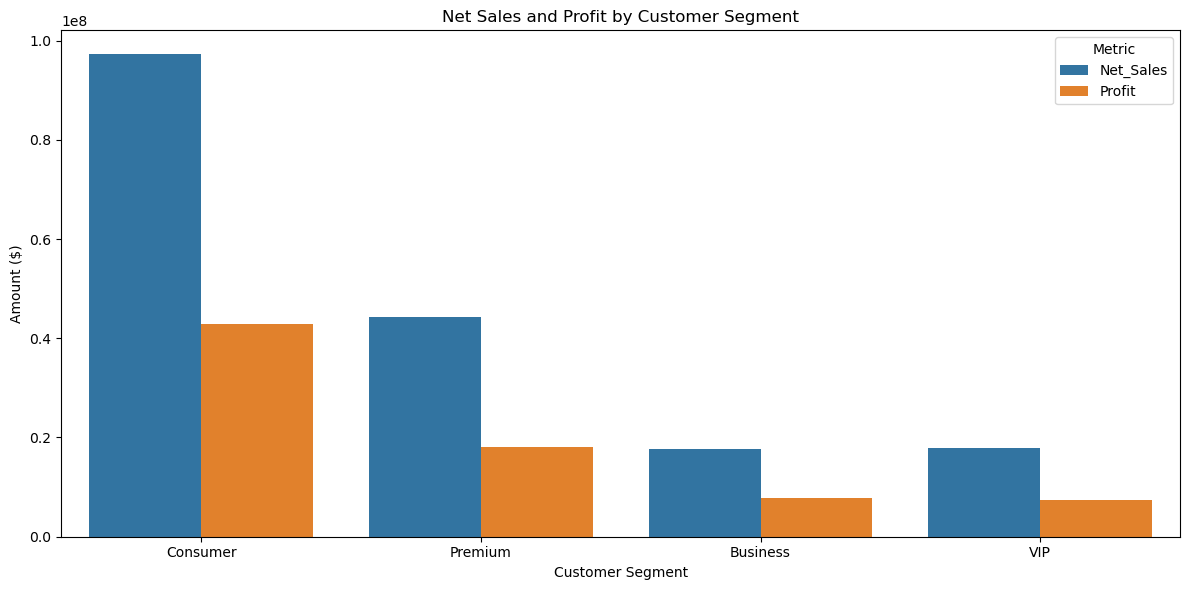

In [11]:
# Customer segment sales and profit comparison
df_segment = segment_performance[['Net_Sales', 'Profit']].reset_index()

df_segment = df_segment.melt(
    id_vars='customer_segment',
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_segment,
    x='customer_segment',
    y='Amount',
    hue='Metric'
)

plt.title('Net Sales and Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Amount ($)')
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

The Consumer segment is the strongest profitability contributor, generating $42.82M in profit from $97.20M in net sales. Although the Premium, Business, and VIP segments maintain comparable profit margins, none matches the Consumer segment in overall profit contribution and sales scale.

In [12]:
##Customer Type Profitability Performance

In [13]:
# Customer type profitability performance
customer_type_performance = (
    df.groupby('customer_type')
      .agg(
          Net_Sales=('net_sales', 'sum'),
          Profit=('profit', 'sum'),
          Orders=('order_id', 'nunique')
      )
)

customer_type_performance['Profit_Margin'] = (
    customer_type_performance['Profit'] /
    customer_type_performance['Net_Sales']
)

customer_type_performance = customer_type_performance.sort_values(
    'Profit',
    ascending=False
)

customer_type_performance

,Net_Sales,Profit,Orders,Profit_Margin
customer_type,,,,
Loyal,1.661754e+08,71438627.72,129447,0.429899
Returning,1.052336e+07,4515027.31,8335,0.429048
New,4.354568e+05,192740.73,334,0.442617


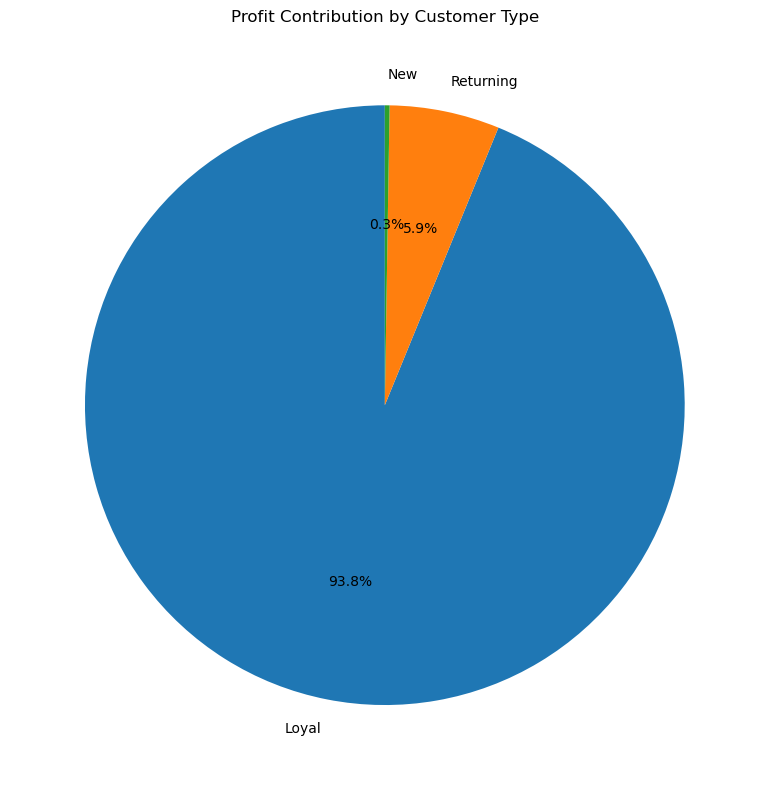

In [14]:
# Customer type profit contribution
profit_by_type = customer_type_performance['Profit']

plt.figure(figsize=(8, 8))

plt.pie(
    profit_by_type,
    labels=profit_by_type.index,
    autopct='%.1f%%',
    startangle=90
)

plt.title('Profit Contribution by Customer Type')

plt.tight_layout()
plt.show()

In [15]:
# Regional sales and profitability performance
regional_performance = (
    df.groupby('region')
      .agg(
          Net_Sales=('net_sales', 'sum'),
          Profit=('profit', 'sum'),
          Orders=('order_id', 'nunique')
      )
)

regional_performance['Profit_Margin'] = (
    regional_performance['Profit'] /
    regional_performance['Net_Sales']
)

regional_performance = regional_performance.sort_values(
    'Profit',
    ascending=False
)

regional_performance

,Net_Sales,Profit,Orders,Profit_Margin
region,,,,
South,55587994.98,23343946.17,43990,0.419946
West,34755096.47,15647252.47,26273,0.450215
Central,37171107.17,15572868.84,29627,0.418951
East,27054887.88,11179366.94,21602,0.413211
North,22565177.24,10402961.34,16624,0.461018


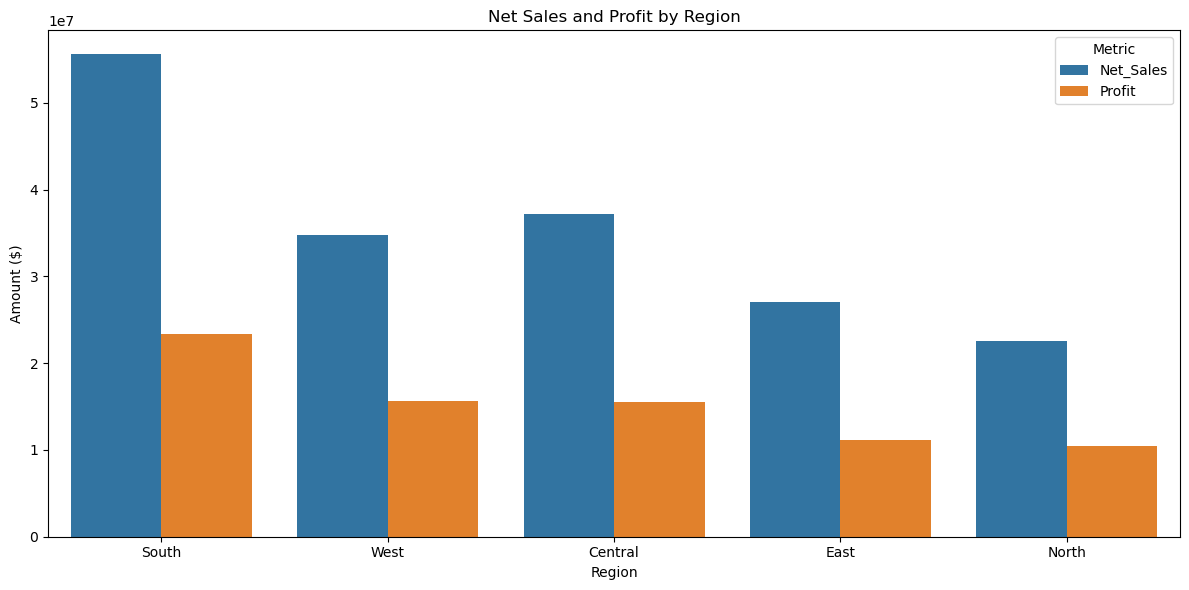

In [16]:
# Regional sales and profit comparison
df_region = regional_performance[['Net_Sales', 'Profit']].reset_index()

df_region = df_region.melt(
    id_vars='region',
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_region,
    x='region',
    y='Amount',
    hue='Metric'
)

plt.title('Net Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

South drives the most profit because of its larger sales volume, while North is the most profitable region on a margin basis. East and Central warrant further investigation because they combine substantial sales with comparatively lower profit margins.

In [17]:
# Confirm the discount field used for analysis
df['discount_amount'].describe()

count    138116.000000
mean        237.621614
std         378.779459
min           0.000000
25%          26.327500
50%         103.285000
75%         277.125000
max        6759.020000
Name: discount_amount, dtype: float64

In [18]:
# Calculate effective discount rate
df['discount_rate'] = np.where(
    df['gross_sales'] > 0,
    df['discount_amount'] / df['gross_sales'],
    0
)

df['discount_rate'].describe()

count    138116.000000
mean          0.151171
std           0.122872
min           0.000000
25%           0.065440
50%           0.127478
75%           0.205983
max           0.600199
Name: discount_rate, dtype: float64

In [19]:
# Create discount bands for profitability analysis
df['discount_band'] = pd.cut(
    df['discount_rate'],
    bins=[-0.001, 0, 0.10, 0.20, 0.30, 1],
    labels=['No Discount', 'Low (1-10%)', 'Medium (11-20%)', 'High (21-30%)', 'Very High (31%+)']
)

In [20]:
# Evaluate profitability across discount bands
discount_performance = (
    df.groupby('discount_band', observed=True)
      .agg(
          Net_Sales=('net_sales', 'sum'),
          Profit=('profit', 'sum'),
          Orders=('order_id', 'nunique')
      )
)

discount_performance['Profit_Margin'] = (
    discount_performance['Profit'] /
    discount_performance['Net_Sales']
)

discount_performance

,Net_Sales,Profit,Orders,Profit_Margin
discount_band,,,,
No Discount,24529544.79,12899973.52,17864,0.525895
Low (1-10%),44374712.26,21851907.05,35031,0.492441
Medium (11-20%),59606722.44,26735325.41,49198,0.448529
High (21-30%),23851740.64,8970901.10,17729,0.376111
Very High (31%+),24771543.61,5688288.68,18294,0.229630


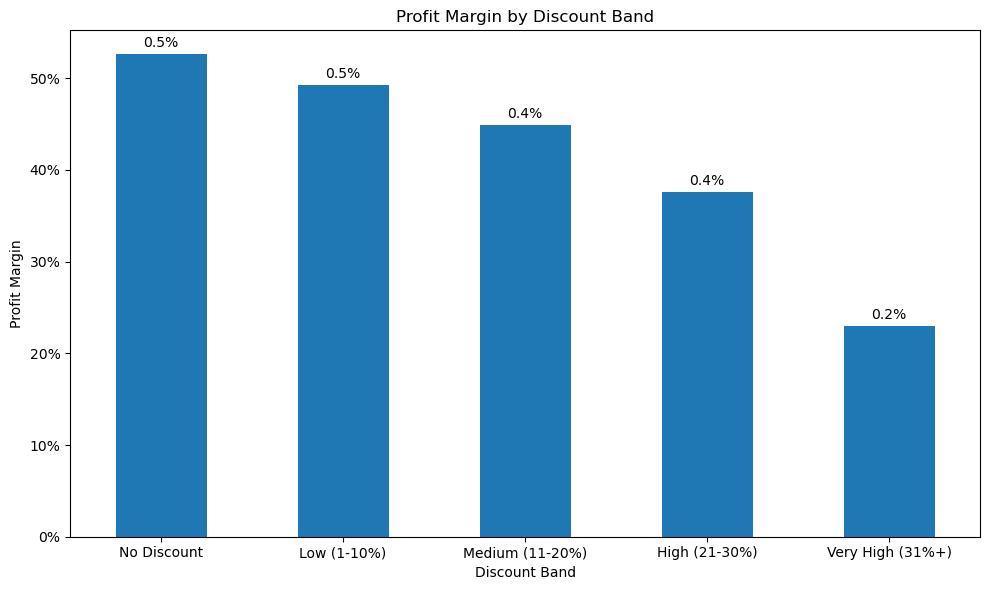

In [21]:
# Profit margin by discount band
ax = discount_performance['Profit_Margin'].plot(
    kind='bar',
    figsize=(10, 6)
)

ax.set_title('Profit Margin by Discount Band')
ax.set_xlabel('Discount Band')
ax.set_ylabel('Profit Margin')
ax.yaxis.set_major_formatter(
    ticker.PercentFormatter(1.0)
)
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

Profitability declines progressively as discount rates increase. Transactions with discounts above 30% generate a 22.96% profit margin compared with 52.59% for transactions without discounts, indicating that aggressive discounting significantly erodes profitability.

##Loss Analysis.

In [22]:
# Regional loss contribution
regional_losses = (
    df[df['profit'] < 0]
    .groupby('region')
    .agg(
        Loss=('profit', 'sum'),
        Loss_Transactions=('profit', 'size')
    )
)

regional_losses['Loss_Contribution'] = (
    regional_losses['Loss'].abs() /
    regional_losses['Loss'].abs().sum()
)

regional_losses = regional_losses.sort_values(
    'Loss',
    ascending=True
)

regional_losses

,Loss,Loss_Transactions,Loss_Contribution
region,,,
South,-72893.91,477,0.362250
Central,-43550.08,293,0.216424
East,-39003.63,236,0.193831
West,-26913.59,178,0.133749
North,-18864.13,112,0.093746


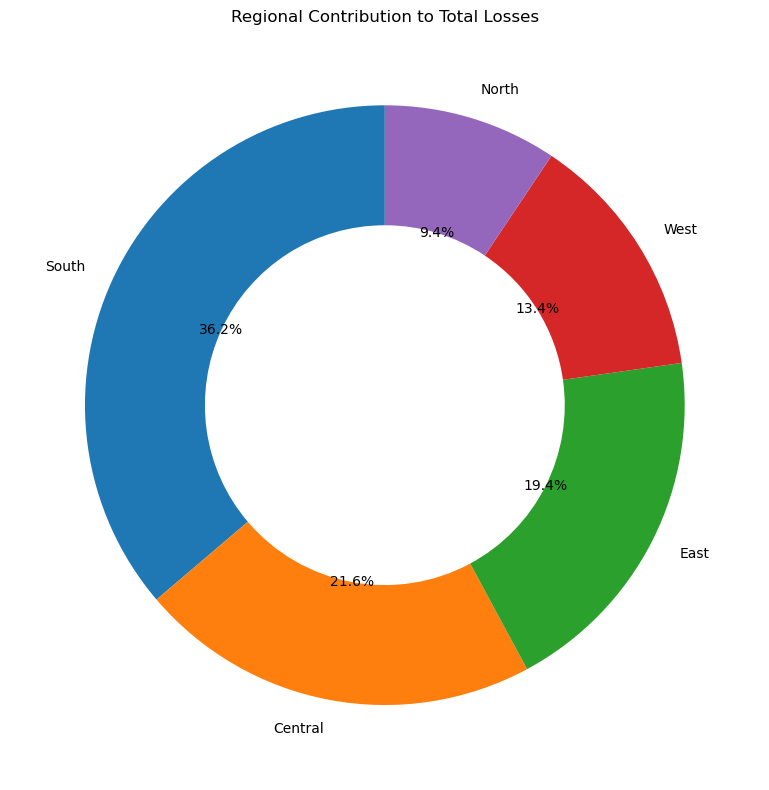

In [23]:
# Regional contribution to total losses
loss_contribution = regional_losses['Loss'].abs()

plt.figure(figsize=(8, 8))

plt.pie(
    loss_contribution,
    labels=loss_contribution.index,
    autopct='%.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Regional Contribution to Total Losses')

plt.tight_layout()
plt.show()

Losses are concentrated in the South, Central, and East regions, which together account for approximately 77% of total losses. The South alone contributes 36.23%, making it the highest-priority region for investigating the causes of loss-making transactions.

In [24]:
##Loss Analysis by Discount Band

In [25]:
# Loss contribution by discount band
loss_by_discount = (
    df[df['profit'] < 0]
    .groupby('discount_band', observed=True)
    .agg(
        Loss=('profit', 'sum'),
        Loss_Transactions=('profit', 'size')
    )
)

loss_by_discount['Loss_Contribution'] = (
    loss_by_discount['Loss'].abs() /
    loss_by_discount['Loss'].abs().sum()
)

loss_by_discount

,Loss,Loss_Transactions,Loss_Contribution
discount_band,,,
Very High (31%+),-201225.34,1296,1.0


All identified financial losses are concentrated in transactions with discount rates above 31%, making aggressive discounting the strongest identified driver of loss-making transactions.

In [26]:
##High-Discount Losses by Region

In [27]:
# Regional concentration of high-discount losses
high_discount_losses = (
    df[(df['profit'] < 0) & (df['discount_rate'] > 0.30)]
    .groupby('region')
    .agg(
        Loss=('profit', 'sum'),
        Loss_Transactions=('profit', 'size')
    )
)

high_discount_losses['Loss_Contribution'] = (
    high_discount_losses['Loss'].abs() /
    high_discount_losses['Loss'].abs().sum()
)

high_discount_losses = high_discount_losses.sort_values(
    'Loss',
    ascending=True
)

high_discount_losses

,Loss,Loss_Transactions,Loss_Contribution
region,,,
South,-72893.91,477,0.362250
Central,-43550.08,293,0.216424
East,-39003.63,236,0.193831
West,-26913.59,178,0.133749
North,-18864.13,112,0.093746


High-discount losses are concentrated in the South, Central, and East regions, which collectively account for 77.25% of total losses. The South is the highest-priority region, contributing 36.23% of losses and recording the largest number of loss-making transactions.

In [28]:
# Customer type concentration of loss-making transactions
loss_by_customer_type = (
    df[df['profit'] < 0]
    .groupby('customer_type')
    .agg(
        Loss=('profit', 'sum'),
        Loss_Transactions=('profit', 'size')
    )
)

loss_by_customer_type['Loss_Contribution'] = (
    loss_by_customer_type['Loss'].abs() /
    loss_by_customer_type['Loss'].abs().sum()
)

loss_by_customer_type = loss_by_customer_type.sort_values(
    'Loss',
    ascending=True
)

loss_by_customer_type

,Loss,Loss_Transactions,Loss_Contribution
customer_type,,,
Loyal,-188133.91,1213,0.934941
Returning,-12841.00,80,0.063814
New,-250.43,3,0.001245


Loyal customers account for 93.49% of total losses, indicating that loss-making transactions are overwhelmingly concentrated within the business's most established customer base. This suggests that the issue is more likely related to the commercial terms offered to these customers particularly aggressive discountingthan to customer acquisition.

In [29]:
# Loss concentration by customer type and region
loss_type_region = (
    df[df['profit'] < 0]
    .groupby(['customer_type', 'region'])
    .agg(
        Loss=('profit', 'sum'),
        Loss_Transactions=('profit', 'size')
    )
)

loss_type_region['Loss_Contribution'] = (
    loss_type_region['Loss'].abs() /
    loss_type_region['Loss'].abs().sum()
)

loss_type_region.sort_values(
    'Loss',
    ascending=True
)

Loss  Loss_Transactions  Loss_Contribution
customer_type region                                                 
Loyal         South   -69506.41                447           0.345416
              Central -41053.41                272           0.204017
              East    -34746.12                221           0.172673
              West    -24724.24                167           0.122868
              North   -18103.73                106           0.089967
Returning     East     -4016.61                 14           0.019961
              South    -3387.50                 30           0.016834
              Central  -2492.86                 20           0.012388
              West     -2189.35                 11           0.010880
              North     -754.68                  5           0.003750
New           East      -240.90                  1           0.001197
              North       -5.72                  1           0.000028
              Central     -3.81                  1           0.000019

Loyal customers in the South represent the single largest loss concentration, accounting for 34.54% of total losses. More broadly, losses from Loyal customers dominate across every region, confirming that the loss problem is concentrated within the established customer base rather than being driven by new-customer activity.

In [30]:
# Loss concentration by marketing channel
loss_by_marketing = (
    df[df['profit'] < 0]
    .groupby('marketing_channel')
    .agg(
        Loss=('profit', 'sum'),
        Loss_Transactions=('profit', 'size')
    )
)

loss_by_marketing['Loss_Contribution'] = (
    loss_by_marketing['Loss'].abs() /
    loss_by_marketing['Loss'].abs().sum()
)

loss_by_marketing = loss_by_marketing.sort_values(
    'Loss',
    ascending=True
)

loss_by_marketing

,Loss,Loss_Transactions,Loss_Contribution
marketing_channel,,,
Organic Search,-43893.40,266,0.218131
Google Ads,-35054.31,223,0.174204
Direct,-28158.56,189,0.139935
Facebook Ads,-26110.99,164,0.129760
Instagram,-18007.28,114,0.089488
Email Marketing,-15738.66,113,0.078214
Referral,-13940.15,104,0.069276
TikTok,-8973.33,42,0.044593
Affiliate,-7924.99,47,0.039384


Losses are broadly distributed across marketing channels, with Organic Search, Google Ads, and Direct accounting for the largest shares. The evidence suggests that discount policy is a more fundamental driver of losses than marketing channel alone.

In [31]:
# Identify the largest loss-making transactions
largest_losses = (
    df[df['profit'] < 0]
    [['order_id', 'customer_id', 'region', 'customer_type',
      'discount_rate', 'net_sales', 'profit']]
    .sort_values('profit')
    .head(20)
)

largest_losses

,order_id,customer_id,region,customer_type,discount_rate,net_sales,profit
21167,ORD-750525,CUST-007260,East,Loyal,0.559377,4142.76,-1281.59
24838,ORD-556742,CUST-001272,South,Loyal,0.600000,2530.57,-1229.49
22177,ORD-780785,CUST-004057,North,Loyal,0.600000,2655.59,-1205.83
108658,ORD-480427,CUST-009305,East,Loyal,0.535529,3668.16,-1172.13
81263,ORD-550155,CUST-004967,South,Loyal,0.542114,3825.41,-1163.92
109080,ORD-817113,CUST-001941,South,Loyal,0.582782,2353.09,-1096.01
77976,ORD-415091,CUST-010280,Central,Loyal,0.557526,2783.12,-1051.57
52408,ORD-683198,CUST-014450,North,Loyal,0.584725,3683.67,-1051.49
50212,ORD-260655,CUST-017226,East,Loyal,0.575454,2751.44,-1034.29
76608,ORD-420869,CUST-019894,East,Loyal,0.558710,2805.41,-1032.00


The largest loss-making transactions consistently involve Loyal customers receiving discounts above 50%, providing strong transaction-level evidence that excessive discounting is eroding profitability.

In [32]:
# Analyze the relationship between discount rate and profit
discount_profit = (
    df.groupby('discount_band', observed=True)
      .agg(
          Avg_Discount=('discount_rate', 'mean'),
          Avg_Profit=('profit', 'mean'),
          Total_Profit=('profit', 'sum'),
          Transactions=('profit', 'size')
    )
)

discount_profit

,Avg_Discount,Avg_Profit,Total_Profit,Transactions
discount_band,,,,
No Discount,0.000000,722.121223,12899973.52,17864
Low (1-10%),0.063471,623.787704,21851907.05,35031
Medium (11-20%),0.144533,543.423013,26735325.41,49198
High (21-30%),0.243865,506.001529,8970901.10,17729
Very High (31%+),0.394745,310.937394,5688288.68,18294


Discounting has a clear negative relationship with transaction-level profitability. As discount rates increase, average profit consistently declines, with transactions above 31% discount generating less than half the average profit of transactions without discounts.

In [33]:
# Compare sales volume and profitability across discount bands
discount_tradeoff = (
    df.groupby('discount_band', observed=True)
      .agg(
          Net_Sales=('net_sales', 'sum'),
          Profit=('profit', 'sum'),
          Transactions=('profit', 'size')
      )
)

discount_tradeoff['Profit_Margin'] = (
    discount_tradeoff['Profit'] /
    discount_tradeoff['Net_Sales']
)

discount_tradeoff

,Net_Sales,Profit,Transactions,Profit_Margin
discount_band,,,,
No Discount,24529544.79,12899973.52,17864,0.525895
Low (1-10%),44374712.26,21851907.05,35031,0.492441
Medium (11-20%),59606722.44,26735325.41,49198,0.448529
High (21-30%),23851740.64,8970901.10,17729,0.376111
Very High (31%+),24771543.61,5688288.68,18294,0.229630


Higher discount levels generate sales, but the additional sales do not compensate for the substantial erosion in profitability. Discounts above 30% are particularly inefficient, producing only slightly more sales than the 21–30% band while reducing profit margin by approximately 14.65 percentage points.

In [36]:
# Format coupon performance for presentation
coupon_performance.style.format({
    'Net_Sales': '${:,.2f}',
    'Profit': '${:,.2f}',
    'Transactions': '{:,.0f}',
    'Avg_Discount': '{:.2%}',
    'Profit_Margin': '{:.2%}'
})

,Net_Sales,Profit,Transactions,Avg_Discount,Profit_Margin
Coupon_Status,,,,,
Coupon Recorded,"$35,255,401.72","$15,188,673.21","27,614",15.10%,43.08%
No Coupon Recorded,"$141,878,862.02","$60,957,722.55","110,502",15.12%,42.96%


In [50]:
# Aggregate coupon-level performance and assess profitability
coupon_analysis = (
    df[df['coupon_code'].notna()]
    .groupby('coupon_code')
    .agg(
        Net_Sales=('net_sales', 'sum'),
        Profit=('profit', 'sum'),
        Transactions=('coupon_code', 'size'),
        Avg_Discount=('discount_rate', 'mean')
    )
)

coupon_analysis['Profit_Margin'] = (
    coupon_analysis['Profit'] / coupon_analysis['Net_Sales']
)

coupon_analysis = coupon_analysis.sort_values(
    'Profit_Margin',
    ascending=False
)

correlation = coupon_analysis[
    ['Avg_Discount', 'Profit_Margin']
].corr().loc['Avg_Discount', 'Profit_Margin']

print(f"Correlation between average coupon discount and profit margin: {correlation:.3f}")

Correlation between average coupon discount and profit margin: -0.489


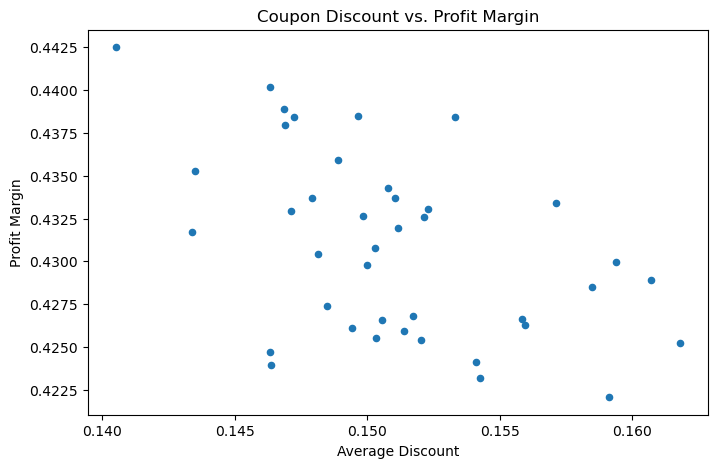

In [51]:
# Assess the relationship between coupon discount and profitability
coupon_analysis.plot(
    kind='scatter',
    x='Avg_Discount',
    y='Profit_Margin',
    figsize=(8, 5)
)

plt.title('Coupon Discount vs. Profit Margin')
plt.xlabel('Average Discount')
plt.ylabel('Profit Margin')
plt.show()

Coupon-level analysis shows a moderate negative relationship between average discount and profit margin (r = −0.489). Coupons with higher average discounts generally achieve lower profit margins, reinforcing the broader finding that increased discounting can erode profitability. However, the relationship is not strong enough to establish causation, as other factors may influence coupon-level profitability.

## Recommendation

The business should adopt a **profitability-focused discount strategy** rather than relying on aggressive promotions to drive sales. Discounts above 30% require particular scrutiny, as they are strongly associated with lower margins and account for all identified loss-making transactions.

Promotional offers should be targeted based on customer value, region, and expected profitability, while coupon campaigns should focus on controlling the **size of the discount** rather than simply increasing coupon usage.

The objective should be to **maximize profitable sales, not sales volume alone**.
